# Cell Voltage Exploratory Data Analysis
**Date:** 2026-03-03 | **Session duration:** 14 min | **Pack:** 84-cell

## Summary
Pack behavior appears healthy overall, though several cells warrant closer monitoring.
See conclusions for details.

**Imports & configs**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bms_utils as B

B.apply_lsu_style()
PATH = '../data/raw/cellvoltages_2026-03-03-21-21-48.csv'

**Load**

In [2]:
df = B.load_session(PATH)
df['elapsed_m'] = df['elapsed_s'] / 60
print(f'Duration: {df["elapsed_s"].max() / 60:.1f} min  ({len(df)} rows)')
print(df.isnull().sum().sum(), 'total missing values')
df.head()

Duration: 14.0 min  (1807 rows)
0 total missing values


,Time,State of Charge,Pack Voltage,Pack Current,Pack CCL,Pack DCL,Highest Cell ID,Highest Cell Volt,Lowest Cell ID,Lowest Cell Volt,...,Open Cell Voltage 78,Open Cell Voltage 79,Open Cell Voltage 80,Open Cell Voltage 81,Open Cell Voltage 82,Open Cell Voltage 83,Open Cell Voltage 84,elapsed_s,session_id,elapsed_m
0,2026-03-03 21:21:53,50.0,296.9,-0.2,6,198,14,3.5380,9,3.5056,...,3.5363,3.5348,3.5367,3.5339,3.5361,3.5348,3.5334,0.0,2026-03-03-21-21-48,0.000000
1,2026-03-03 21:21:54,50.0,296.8,-0.0,6,198,14,3.5381,9,3.5055,...,3.5363,3.5348,3.5367,3.5339,3.5361,3.5348,3.5334,1.0,2026-03-03-21-21-48,0.016667
2,2026-03-03 21:21:54,50.0,296.8,0.3,6,198,14,3.5381,9,3.5055,...,3.5362,3.5348,3.5366,3.5339,3.5360,3.5349,3.5332,1.0,2026-03-03-21-21-48,0.016667
3,2026-03-03 21:21:54,50.0,296.8,0.3,6,198,14,3.5380,9,3.5055,...,3.5362,3.5348,3.5366,3.5339,3.5360,3.5349,3.5332,1.0,2026-03-03-21-21-48,0.016667
4,2026-03-03 21:21:55,50.0,296.8,0.3,6,198,14,3.5381,9,3.5055,...,3.5362,3.5348,3.5366,3.5339,3.5360,3.5349,3.5332,2.0,2026-03-03-21-21-48,0.033333


**Pack Current & Voltage Over Time**

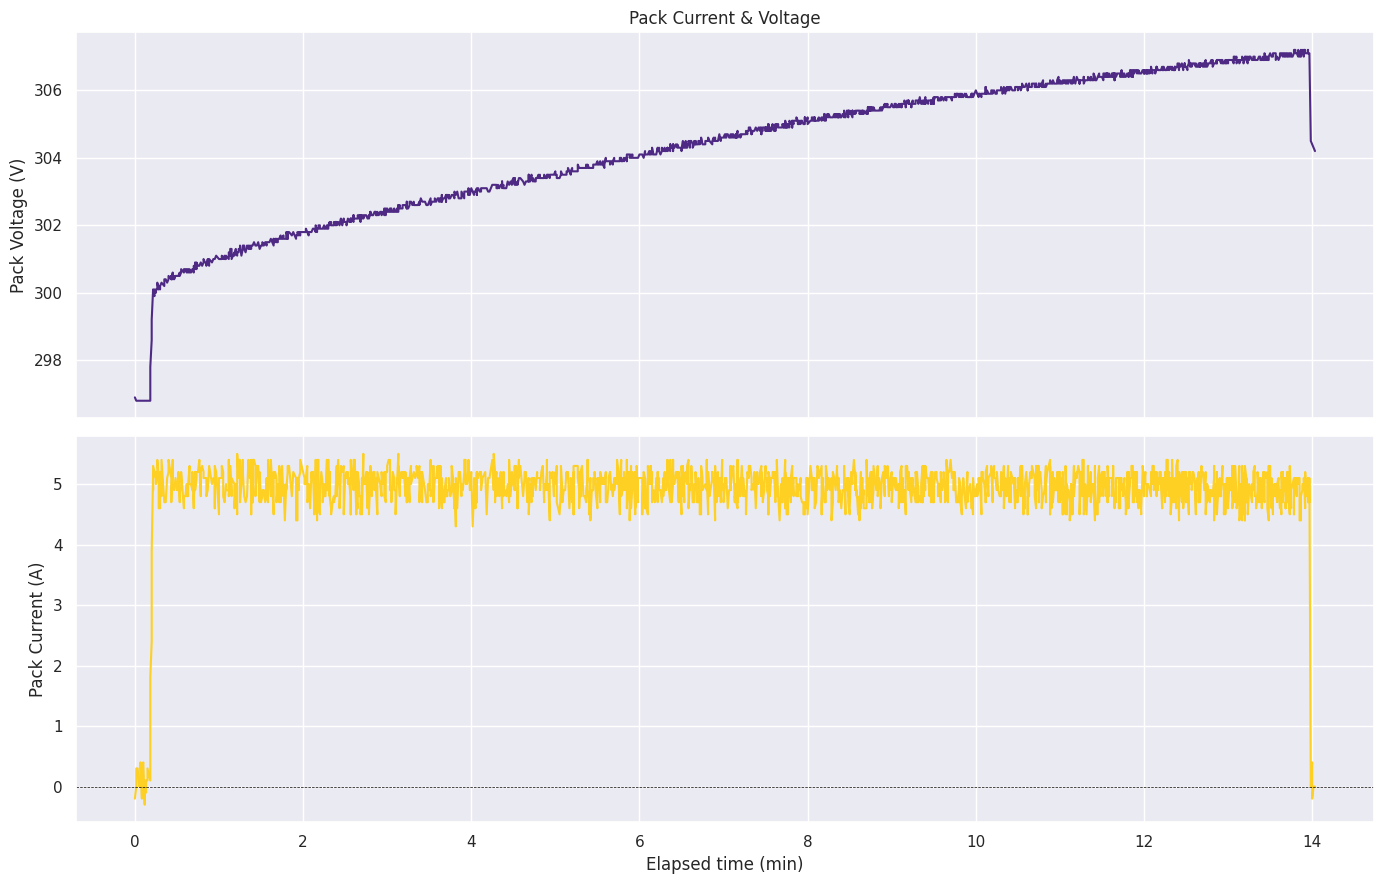

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
axes[0].plot(df['elapsed_m'], df['Pack Voltage'])
axes[0].set_ylabel('Pack Voltage (V)')
axes[0].set_title('Pack Current & Voltage')
axes[1].plot(df['elapsed_m'], df['Pack Current'], color='#FDD023')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Pack Current (A)')
axes[1].set_xlabel('Elapsed time (min)')
plt.tight_layout()
plt.show()

**Voltage Spread Over Time**

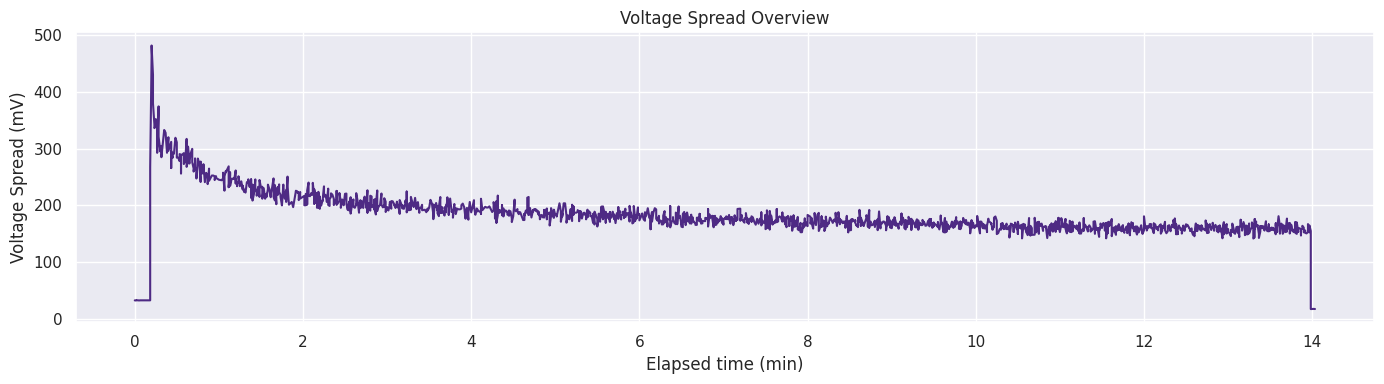

In [4]:
df['Voltage Spread'] = df['Highest Cell Volt'] - df['Lowest Cell Volt']
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.plot(df['elapsed_m'], df['Voltage Spread'] * 1000)
ax.set_title('Voltage Spread Overview')
ax.set_ylabel('Voltage Spread (mV)')
ax.set_xlabel('Elapsed time (min)')
plt.tight_layout()
plt.show()

**Mean Voltage And Mean Rank Per Cell**

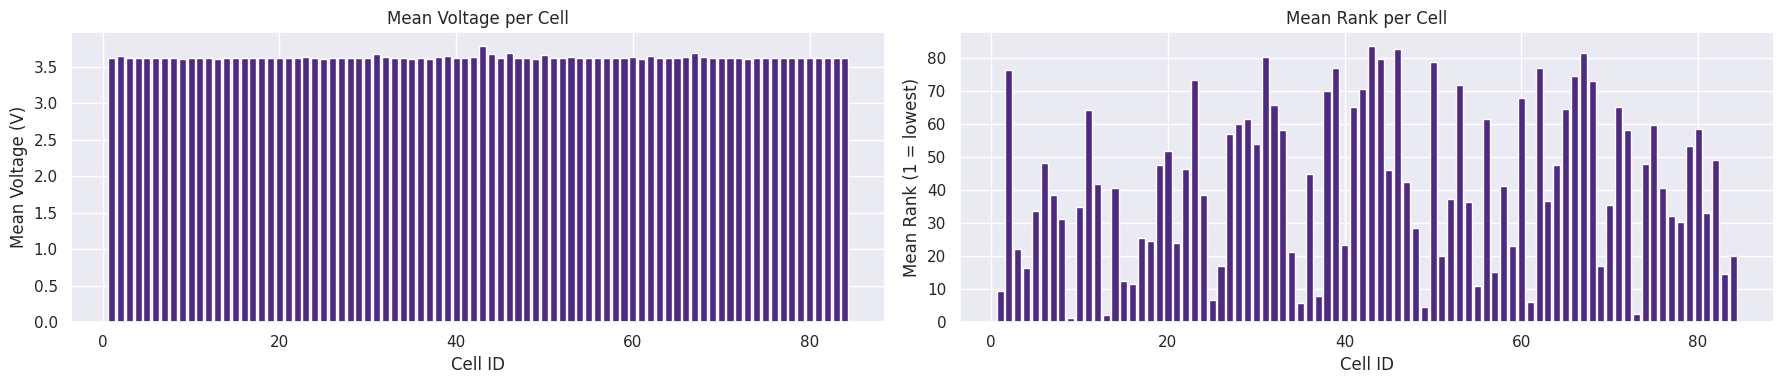

In [5]:
cell_mean_voltage = B.cell_mean_voltage(df)
cell_mean_rank = B.cell_mean_rank(df)
CELL_IDS = range(1, B.N_CELLS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))
ax1.bar(CELL_IDS, cell_mean_voltage)
ax1.set_title('Mean Voltage per Cell')
ax1.set_xlabel('Cell ID')
ax1.set_ylabel('Mean Voltage (V)')

ax2.bar(CELL_IDS, cell_mean_rank)
ax2.set_title('Mean Rank per Cell')
ax2.set_xlabel('Cell ID')
ax2.set_ylabel('Mean Rank (1 = lowest)')

plt.tight_layout()
plt.show()

**Mean Cell Rank Distribution**

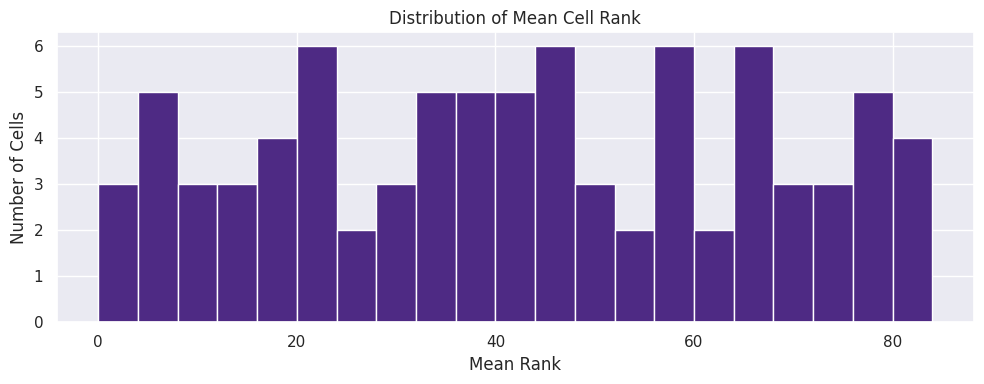

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cell_mean_rank, bins=range(0, 85, 4))
ax.set_title('Distribution of Mean Cell Rank')
ax.set_xlabel('Mean Rank')
ax.set_ylabel('Number of Cells')
plt.tight_layout()
plt.show()

**Cell Voltage By Z-Score (Std Deviations From Pack Mean)**

Most-below pack mean (z-score):
Cell Voltage 9    -1.097
Cell Voltage 13   -0.937
Cell Voltage 73   -0.919
Cell Voltage 49   -0.695
Cell Voltage 35   -0.668
dtype: float64

Most-above pack mean (z-score):
Cell Voltage 43    6.911
Cell Voltage 46    2.752
Cell Voltage 67    2.477
Cell Voltage 31    2.016
Cell Voltage 44    1.863
dtype: float64


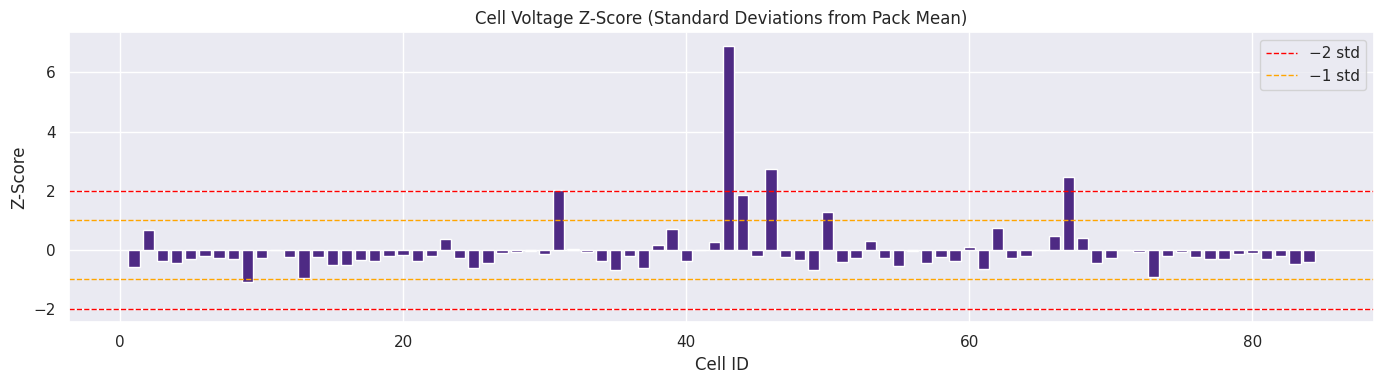

In [7]:
z_scores = B.cell_voltage_z(df)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(1, B.N_CELLS + 1), z_scores)
ax.axhline(-2, color='red',    linestyle='--', linewidth=1, label='−2 std')
ax.axhline(-1, color='orange', linestyle='--', linewidth=1, label='−1 std')
ax.axhline( 1, color='orange', linestyle='--', linewidth=1)
ax.axhline( 2, color='red',    linestyle='--', linewidth=1)
ax.set_title('Cell Voltage Z-Score (Standard Deviations from Pack Mean)')
ax.set_xlabel('Cell ID')
ax.set_ylabel('Z-Score')
ax.legend()

print('Most-below pack mean (z-score):')
print(z_scores.nsmallest(5).round(3))
print('\nMost-above pack mean (z-score):')
print(z_scores.nlargest(5).round(3))
plt.tight_layout()
plt.show()

**Voltage Of Special Cells Vs Pack Mean Voltage**

Mean Voltage of Weakest Cells (V)
Cell Voltage 9     3.6000
Cell Voltage 13    3.6036
Cell Voltage 73    3.6040
Cell Voltage 49    3.6091
Cell Voltage 35    3.6097
dtype: float64

Mean Rank of Weakest Cells (1-84)
Cell Voltage 9     1.40
Cell Voltage 13    2.12
Cell Voltage 73    2.52
Cell Voltage 49    4.51
Cell Voltage 35    5.92
dtype: float64


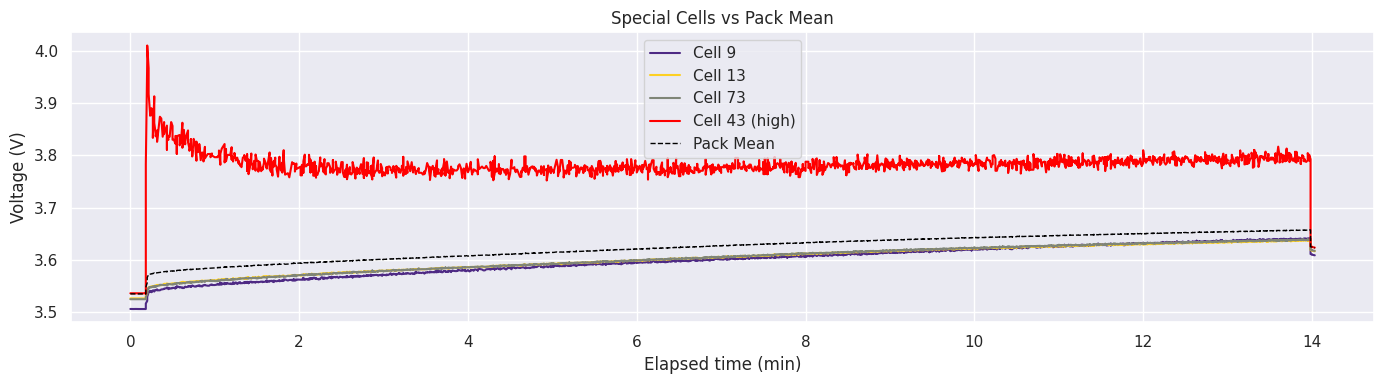

In [8]:
print('Mean Voltage of Weakest Cells (V)')
print(cell_mean_voltage.nsmallest(5).round(4))
print('\nMean Rank of Weakest Cells (1-84)')
print(cell_mean_rank.nsmallest(5).round(2))

pack_mean = df[B.CV_COLS].mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['elapsed_m'], df['Cell Voltage 9'],  label='Cell 9')
ax.plot(df['elapsed_m'], df['Cell Voltage 13'], label='Cell 13')
ax.plot(df['elapsed_m'], df['Cell Voltage 73'], label='Cell 73')
ax.plot(df['elapsed_m'], df['Cell Voltage 43'], label='Cell 43 (high)', color='red')
ax.plot(df['elapsed_m'], pack_mean, label='Pack Mean', color='black', linestyle='--', linewidth=1)
ax.set_title('Special Cells vs Pack Mean')
ax.set_xlabel('Elapsed time (min)')
ax.set_ylabel('Voltage (V)')
ax.legend()
plt.tight_layout()
plt.show()

**Load residual (V_loaded − OCV)**

Per-cell median voltage delta under load (`|Pack Current| ≥ 1 A`), in millivolts.
A cell that sags more than its peers at the same pack current is showing elevated
internal resistance and is worth flagging even if its mean voltage looks normal.

Largest |load residual| (mV):
53    0.35
19    0.30
28    0.30
7     0.30
42    0.30
59    0.30
65    0.30
63    0.30
Name: load_residual_mV, dtype: float64


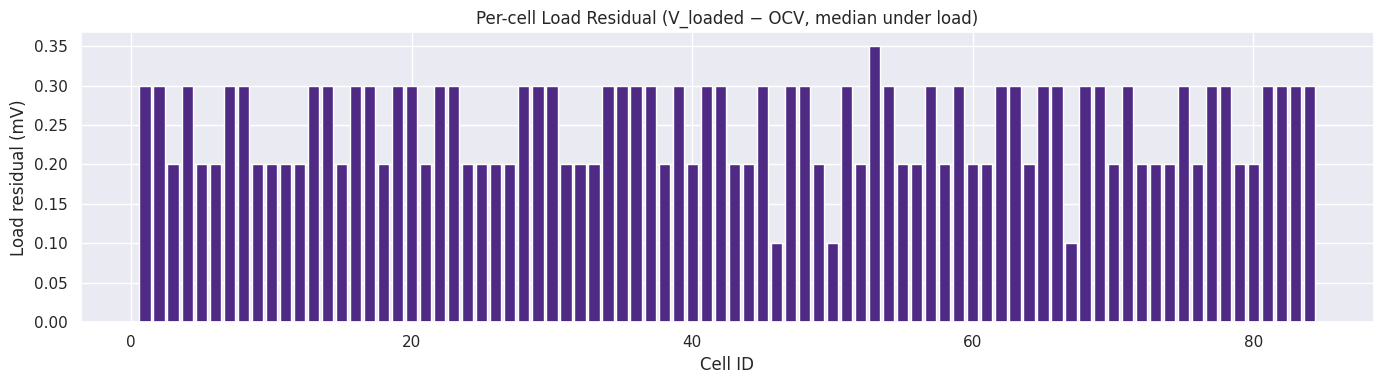

In [9]:
load_residual = B.load_residual_mv(df, min_abs_current_a=1.0)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(1, B.N_CELLS + 1), load_residual.to_numpy())
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Per-cell Load Residual (V_loaded − OCV, median under load)')
ax.set_xlabel('Cell ID')
ax.set_ylabel('Load residual (mV)')
plt.tight_layout()

print('Largest |load residual| (mV):')
print(load_residual.reindex(load_residual.abs().sort_values(ascending=False).head(8).index).round(3))
plt.show()

## Conclusion
### **Pack Health Overview**
The pack charges cleanly with narrowing cell voltage spread over time, indicating
healthy balancing. The distribution of mean cell ranks is roughly uniform,
suggesting weak performance of specific cells is not a major concern as of now.

### **Cell 43**
Cell 43 registered as ~6.9 standard deviations above pack mean. Cell 43 voltage
reaches as high as 4.0 V and remains consistently and significantly above the
pack mean. Suspected causes are that cell 43 is being overcharged or has lower
capacity and hits higher voltage faster. This suggests cell 43 may be more
likely to degrade in the future and is statistically significant enough to
warrant further analysis.

### **Cells 31, 67** (early lead on the high side)
Cells 31 and 67 register +2.0σ and +2.5σ above pack mean — small in absolute
terms but the next-largest positive outliers after cell 43. Worth tracking via
`trends.ipynb`; the same elevated-then-collapse signature is what cell 43 is
showing today.

### **Cells 9, 13, 73**
Mean voltages of cells 9, 13, and 73 underperform the pack mean by ~20–35 mV,
amounting to only ~one standard deviation. Not actionable on their own, but
worth carrying forward.

### **Notes & Next Steps**
**Note:** A single 14-minute charging session is insufficient to draw firm
conclusions, though cell 43's behavior is anomalous enough to warrant immediate
attention regardless.

**Next steps:** Re-run this notebook on future session exports to track whether
the same cells consistently underperform before taking action. Cell 43 should
be monitored closely; if it continues to register significantly above pack mean
across future sessions it should be escalated to senior team members.